# Tarea 3: Clasificación de galaxias con una CNN

En esta tarea trabajarán con una versión binaria del dataset [**Galaxy10 DECaLS**](https://astronn.readthedocs.io/en/latest/galaxy10.html). El objetivo es entrenar una red neuronal convolucional simple para clasificar imágenes de galaxias en dos clases:

- **Round Smooth Galaxies**
- **Barred Spiral Galaxies**

La idea no es obtener el mejor modelo posible, sino entender cómo una CNN aprende patrones visuales, cómo se evalúa su desempeño y en qué casos se equivoca.

## Actividades

1. **Exploración de datos**
   - Visualice imágenes aleatorias de ambas clases
   - ¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?
   - ¿Qué características espera que pueda aprender la red?
   - ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?
     
2. **Preparación de datos**
   - Separe los datos en conjuntos de entrenamiento, validación y test
   - Justifique brevemente por qué es importante tener estos tres conjuntos
     
3. **Arquitectura de la red** (ver más abajo **"Guía para diseñar la CNN"**)
   - Entrene una CNN simple para clasificación binaria
   - Describa la arquitectura utilizada e indique:
        - cuántas capas convolucionales usó
        - qué función de activación escogió
        - si usó pooling, dropout u otra técnica
        - qué función de pérdida utilizó
     - Justifique brevemente estas elecciones
       
4. **Entrenamiento**
   - Grafique las curvas de pérdida y accuracy para entrenamiento y validación
   - A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable
     
5. **Evaluación del modelo**
   - Evalúe el modelo en el conjunto de test usando:
        - accuracy
        - matriz de confusión
        - precision, recall y F1-score
    - ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique
      
6. **Análisis de errores**
   - Muestre algunos ejemplos de imágenes mal clasificadas. ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
   - Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución

7. **Comentario final**
   - A partir de sus resultados, discuta brevemente si el modelo parece estar aprendiendo diferencias morfológicas reales entre galaxias suaves y galaxias espirales barradas, o si podría estar usando otros patrones de las imágenes

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

## Configuración de sesión de colab
Debemos trabajar en Google Colab, que tiene la ventaja de tener tensorflow y Keras ya instalado y además levanta un servidor de GPU suficiente para el propósito de esta tarea.  
Para activarlo, debe ir a `Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU`.

Si lo cambió exitosamente, el siguiente comando no debiera ser un array vacío, sino indicar que  `device_type=GPU`

In [2]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#monte su cuenta de google drive para trabajar en una carpeta ahí. Le pedirá autentificación
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Los datos de Galaxy10 DECaLS vienen de un dataset de Kaggle, con las clases que estudiaremos ya seleccionadas. Más detalles [acá.](https://www.kaggle.com/datasets/anth0nym/galaxy10-decals-fork-dataset)

In [4]:
path = "/content/drive/MyDrive/Colab Notebooks/Machine Learning/Tarea 3/Binary_2_5_dataset.h5" #cambie este path al correspondiente suyo, en su carpeta drive

with h5py.File(path, "r") as f:
    images = np.array(f["images"])
    labels = np.array(f["labels"], dtype="int32")

print(images.shape)
print(labels.shape)

classes, counts = np.unique(labels, return_counts=True)
for c, n in zip(classes, counts):
    print(c, n)

(4688, 256, 256, 3)
(4688,)
0 2645
1 2043


## Estructura de los datos

El dataset contiene **4688 imágenes de galaxias**, cada una con tamaño **256 × 256 píxeles** y **3 canales de color**. Por eso, el arreglo de imágenes tiene la forma:

(4688, 256, 256, 3)

In [5]:
# X

In [6]:
X = images
y = labels.astype("int32")

Para visualizar las imágenes

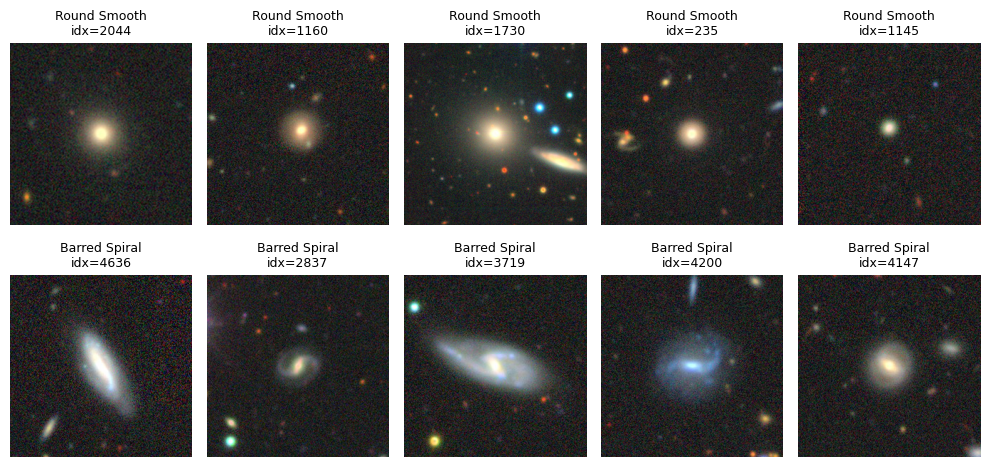

In [7]:
class_names = {
    0: "Round Smooth",
    1: "Barred Spiral"
}

rng = np.random.default_rng(42)  # semilla para que sea reproducible

#Visualiza 5 imágenes aleatorias de cada clase

plt.figure(figsize=(10, 5))

for class_id in [0, 1]:
    idxs = np.where(labels == class_id)[0]
    sample_idxs = rng.choice(idxs, size=5, replace=False)

    for j, idx in enumerate(sample_idxs):
        plt.subplot(2, 5, class_id * 5 + j + 1)
        plt.imshow(images[idx])
        plt.title(f"{class_names[class_id]}\nidx={idx}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

##¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?

Las galaxias Round Smooth se ven como manchas difusas, simetricas y sin estructura interna clara (perfil de luz suave, sin brazos ni barra). Las Barred Spiral muestran una estructura alargada central (la barra) y trazas de brazos espirales o mayor irregularidad en la distribucion de luz.

---

##¿Qué características espera que pueda aprender la red?

Patrones locales de textura y forma como bordes/gradientes de brillo que delimitan la barra central, simetria radial vs. elongacion, y la presencia/ausencia de estructura interna. No se espera que la CNN use color de forma relevante, ya que la diferencia entre clases es principalmente morfologica.

---

##¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?

el dataset tiene 4688 imágenes: 2645 de la clase Round Smooth (56.4%) y 2043 de la clase Barred Spiral (43.6%). Es un desbalance leve, no severo. El accuracy de un clasificador trivial que siempre prediga la clase mayoritaria (Round Smooth) sería de 2645/4688 = 0.564 (56.4%). Este valor sirve como piso de comparación: cualquier modelo entrenado que no supere claramente ese 56.4% de accuracy no estaría aportando información real más allá de la proporción de clases.

## Sets de entrenamiento, validación y prueba

Divida el dataset en entrenamiento, validación y prueba. Verifique que la fracción de las clases es similar en todos los sets

In [8]:
# su codigo acá

# 70% train, 15% val, 15% test, estratificado para mantener la proporcion de clases
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)


In [9]:
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("Train classes:", np.unique(y_train, return_counts=True))
print("Val classes:", np.unique(y_val, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

Train: (3281, 256, 256, 3) (3281,)
Val: (703, 256, 256, 3) (703,)
Test: (704, 256, 256, 3) (704,)
Train classes: (array([0, 1], dtype=int32), array([1851, 1430]))
Val classes: (array([0, 1], dtype=int32), array([397, 306]))
Test classes: (array([0, 1], dtype=int32), array([397, 307]))


Se uso un split estratificado 70% / 15% / 15% (train / val / test), usando stratify=y en ambos llamados a train_test_split para que la proporcion de clases se mantenga igual en los tres conjuntos.

##Por que se necesitan los tres conjuntos:

Entrenamiento: Se usa para ajustar los pesos de la red (backpropagation).

Validacion: Se usa durante el entrenamiento (en cada epoca) para monitorear si el modelo generaliza, y para decisiones como el EarlyStopping — sin tocar el test. Si se usara el test para esto, se estaria "filtrando" informacion del test hacia el proceso de entrenamiento, y la evaluacion final dejaria de ser honesta.

Test: Se usa una unica vez, al final, para obtener una estimacion no sesgada del desempeño del modelo en datos nunca vistos ni por el entrenamiento ni por las decisiones de ajuste de hiperparametros.

## Guía para diseñar la CNN

Para esta tarea deben proponer una red convolucional simple. No existe una única arquitectura correcta, pero su diseño debe estar justificado.

Una CNN para este problema debería incluir, al menos:

- capas convolucionales, para aprender patrones locales en la imagen;
- alguna forma de reducción espacial, como `MaxPooling2D`;
- una parte final densa o de agregación, para hacer la clasificación;
- una capa de salida adecuada para clasificación binaria.

<figure>
  <img src="https://www.astroml.org/astroML-notebooks/_images/fig_cnn_1.png" alt="ejemplo CNN" width="500" height="300">
  <figcaption>Ejemplo arquitectura CNN</figcaption>
</figure>




Al diseñar la arquitectura, responda:

1. ¿Cuántas capas convolucionales usará?  
   ¿Por qué cree que esa profundidad es suficiente para este problema?

2. ¿Cuántos filtros tendrá cada capa convolucional?  
   ¿Usará el mismo número de filtros en todas las capas o aumentará la cantidad de filtros en capas más profundas? Justifique.

3. ¿Qué función de activación usará en las capas internas?  
   ¿Por qué?

4. ¿Usará `MaxPooling2D` u otra forma de reducir el tamaño espacial de los mapas de activación?  
   ¿Qué ventaja tiene esto?

5. ¿Usará `Flatten` o `GlobalAveragePooling2D` antes de la parte densa?  
   ¿Qué diferencia hay entre ambas opciones?

6. ¿Incluirá alguna técnica para reducir overfitting, como `Dropout` o `EarlyStopping`?  
   ¿Por qué podría ser necesaria en este dataset?

7. ¿Qué función de activación debe tener la capa de salida?  
   ¿Por qué esa elección es adecuada para una clasificación binaria?

8. ¿Qué función de pérdida usará?  
   Justifique su elección considerando que el problema tiene dos clases.

### Plantilla de la red
Complete de acuerdo a su elección de la arquitectura.

La capa después de entrada es una capa para normalizar los imágenes. Esto ya que debemos escalar los datos cuando calculamos gradientes, asi la red es más estable, y no depende de los valores de la features.
 Conviene hacerlo en la red misma en vez hacerlo antes, porque en este caso sólo lo hará para las imágenes del batch (los ejemplos que toma para calcular los forward pass y backpropagation). Esto evita que el servidor use todo el RAM disponible

1. ¿Cuántas capas convolucionales usará?  
   ¿Por qué cree que esa profundidad es suficiente para este problema?

   Se usaran 3 capas convolucionales, esta elección se hizo debido a que el tamaño del data set (~3300 imagenes de entrenamiento) y que la diferencia de entre la clase es morfológicamente marcada. En primera instancia no podemos afirmar que 3 capas sean "suficientes", esto lo confirmaremos al observar las curvas de loss/accuracy de entrenamiento y validación, ya que si ambas se estancan en un valor alto, la profundidad sería insuficiente (underfitting) y si el train baja mucho más que val, la capacidad ya sería adecuada o incluso muy alta (overfitting).

2. ¿Cuántos filtros tendrá cada capa convolucional?  
   ¿Usará el mismo número de filtros en todas las capas o aumentará la cantidad de filtros en capas más profundas? Justifique.

   32, 64 y 128 filtros respectivamente de manera creciente. Las capas tempranas detectacaran patrones simples (bordes, gradientes) con pocos filtros y las capas más profundas combinarán esos patrones en features más complejas, lo que ne debería beneficiarse de más filtros.

3. ¿Qué función de activación usará en las capas internas?  
   ¿Por qué?

   ReLu, ya que es computacionalmente barata y evita el problema de gradientes en el cual estos se desvanecen, el cual si afecta a sigmoid/tanh en capas intermedias.

4. ¿Usará `MaxPooling2D` u otra forma de reducir el tamaño espacial de los mapas de activación?  
   ¿Qué ventaja tiene esto?

   Si, MaxPooling2D (2x2) despues de cada bloque convolucional. Esto reduce el número de parámetros y el costo computalcional de las siguentes capas, y aporta cierta invarianza a traslaciones pequeñas del patrón detectado, lo cual es relevante en este caso porque la orientacion de la barra en la imagen no debería cambiar la clase.

5. ¿Usará `Flatten` o `GlobalAveragePooling2D` antes de la parte densa?  
   ¿Qué diferencia hay entre ambas opciones?

   Se usó GlobalAveragePooling2D. Flatten conserva toda la información espacial pero genera un vector muy grande (y por lo tanto una capa densa con muchos parámetros), lo que con ~3300 imágenes de entrenamiento aumenta el riesgo de overfitting. GlobalAveragePooling2D promedia cada mapa de activación a un solo número, reduciendo drásticamente los parámetros de la parte densa, a costa de perder información espacial fina, lo cual debido a la baja complejidad de la morfología de las galaxias del set, no debería ser un problema.

6. ¿Incluirá alguna técnica para reducir overfitting, como `Dropout` o `EarlyStopping`?  
   ¿Por qué podría ser necesaria en este dataset?

   Sí: Dropout(0.3) antes de la capa de salida, y EarlyStopping (monitor=val_loss, patience=3, restore_best_weights=True). Se incluyeron de forma preventiva porque debido al tamaño del dataset, el modelo puede tender a overfitear, esto funciona como precaución para reducir esta tendencia y su efectividad debe de ser juzgada con los resultados finales.

7. ¿Qué función de activación debe tener la capa de salida?  
   ¿Por qué esa elección es adecuada para una clasificación binaria?

   Sigmoid, con una sola neurona de salida. A diferencia de las decisiones anteriores, esta es una necesidad técnica del problema: sigmoid mapea la salida a un valor entre 0 y 1, interpretable directamente como la probabilidad de pertenecer a la clase positiva.

8. ¿Qué función de pérdida usará?  
   Justifique su elección considerando que el problema tiene dos clases.

   `binary_crossentropy`. Es la función matemáticamente correcta para clasificación binaria con salida sigmoid (probabilidad de una sola clase), a diferencia de `categorical_crossentropy`, que se usa cuando hay más de dos clases con salida softmax.

In [142]:
import random

SEED = 420
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [143]:
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)), #capa de entrada, cantidad de neuronas igual a la cantidad de features
    layers.Rescaling(1./255), #capa de normalizacion

    # Bloque convolucional 1
    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    # Bloque convolucional 2
    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    # Bloque convolucional 3
    layers.Conv2D(128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    # Parte final de clasificacion, capa de pooling
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"), #capa densa fully connected
    layers.Dropout(0.3), #regularizacion para reducir overfitting

    # Capa de salida
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary() #resumen de la arquitectura de la red

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_18 (Rescaling)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_18     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [144]:
#regularizacion early stopping de la red https://keras.io/api/callbacks/early_stopping/
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# para correr la red
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, #puede modificar este valor
    batch_size=32,#puede modificar este valor
    callbacks=[early_stop]
)

Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - accuracy: 0.5678 - loss: 0.6828 - val_accuracy: 0.6373 - val_loss: 0.6656
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.7031 - loss: 0.5692 - val_accuracy: 0.7937 - val_loss: 0.4601
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.7699 - loss: 0.4987 - val_accuracy: 0.8137 - val_loss: 0.4369
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.7821 - loss: 0.4777 - val_accuracy: 0.8151 - val_loss: 0.4282
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.7909 - loss: 0.4634 - val_accuracy: 0.8122 - val_loss: 0.4157
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.7995 - loss: 0.4500 - val_accuracy: 0.8122 - val_loss: 0.4054
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.8028 - loss: 0.4387 - val_accuracy: 0.8265 - val_loss: 0.3904
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.8147 - loss: 0.4241 - val_ac

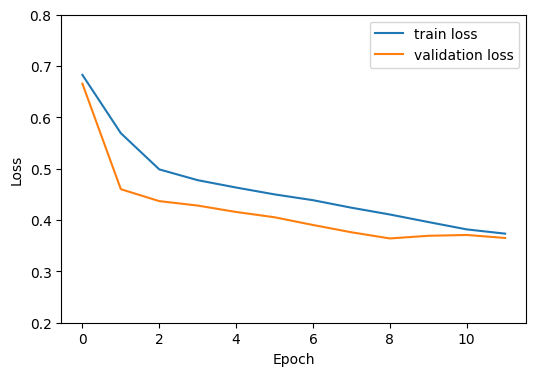

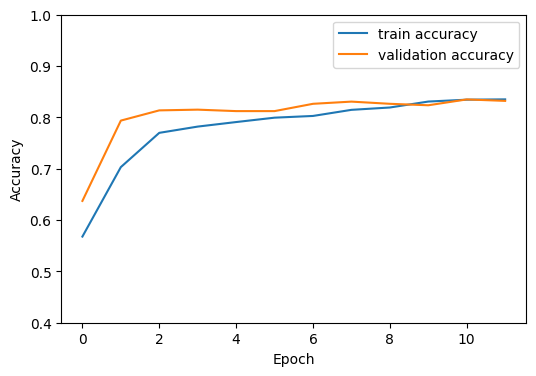

In [145]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim([0.2, 0.8])
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.ylim([0.4, 1])
plt.show()

In [147]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8395 - loss: 0.4154
Test loss: 0.4154
Test accuracy: 0.8395


In [148]:
# Predicciones sobre el set de test (se usan en la matriz de confusion y en el analisis de errores)
y_pred_proba = model.predict(X_test).ravel()
y_pred = (y_pred_proba >= 0.5).astype("int32")

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


##¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique

No, el accuracy por sí solo no es suficiente para evaluar este modelo.
El accuracy reporta un solo número global (83.95%) que indica qué fracción del total de predicciones fueron correctas, pero no dice nada sobre cómo se distribuyen los aciertos y errores entre las dos clases. En un dataset donde las clases no están balanceadas (56.4% Round Smooth vs 43.6% Barred Spiral), un modelo podría obtener un accuracy aparentemente aceptable simplemente sesgándose hacia la clase mayoritaria — prediciendo casi siempre Round Smooth y acertando por pura proporción, sin haber aprendido a distinguir realmente la morfología.
De hecho, el accuracy baseline (predecir siempre la clase mayoritaria sin ningún modelo) es 56.4%. El 83.95% obtenido está claramente por encima de ese piso, lo que indica que el modelo sí está capturando señal real, pero el accuracy solo no responde preguntas como: ¿se equivoca más clasificando galaxias smooth como barred, o al revés? ¿Detecta bien la clase minoritaria (Barred Spiral) o la confunde frecuentemente con la mayoritaria?

Para responder eso se necesitan métricas complementarias:

* Matriz de confusión: muestra explícitamente cuántas galaxias de cada clase fueron correctamente clasificadas y cuántas fueron confundidas con la otra, permitiendo identificar si el modelo tiene un sesgo sistemático hacia una clase.

* Precision: de todas las galaxias que el modelo predijo como Barred Spiral, ¿qué fracción realmente lo era? Un precision bajo indicaría muchos falsos positivos.

* Recall: de todas las galaxias que realmente son Barred Spiral, ¿qué fracción logró detectar? Un recall bajo indicaría que el modelo "se pierde" muchas barred spirals, clasificándolas como smooth.

* F1-score: promedio armónico de precision y recall, útil para evaluar el balance entre ambas métricas por clase, especialmente para la clase minoritaria donde el accuracy global puede enmascarar un desempeño pobre.

#### Genere la matriz de confusión y las métricas

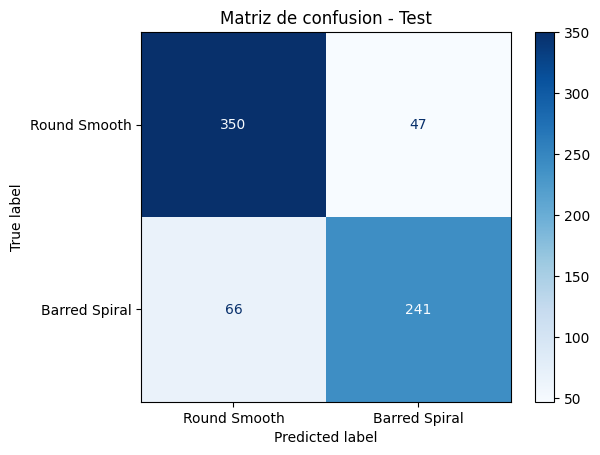

               precision    recall  f1-score   support

 Round Smooth       0.84      0.88      0.86       397
Barred Spiral       0.84      0.79      0.81       307

     accuracy                           0.84       704
    macro avg       0.84      0.83      0.84       704
 weighted avg       0.84      0.84      0.84       704



In [149]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[class_names[0], class_names[1]])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusion - Test")
plt.show()

print(classification_report(y_test, y_pred, target_names=[class_names[0], class_names[1]]))

#### Revise algunos ejemplos de galaxias mal clasificadas

Total mal clasificadas: 113 de 704 (16.05%)


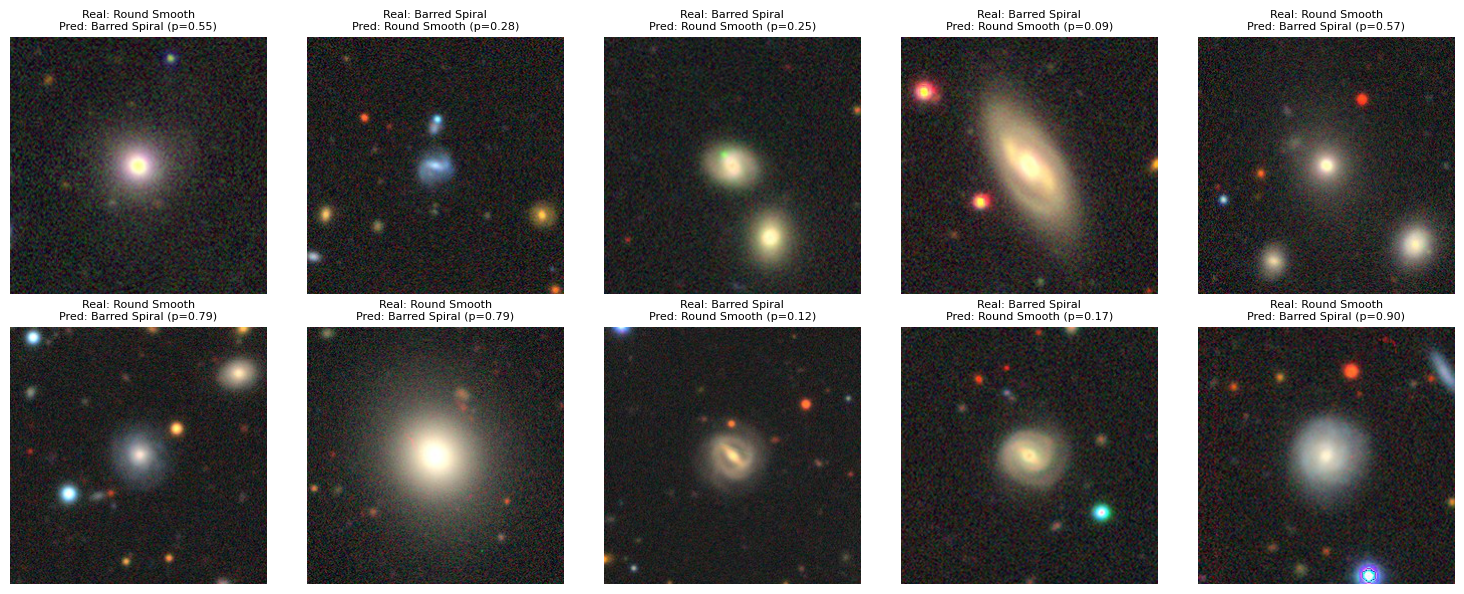

In [150]:
# Indices de imagenes de test mal clasificadas
X_test_idx = np.arange(len(y_test))
misclassified_idx = X_test_idx[y_pred != y_test]

print(f"Total mal clasificadas: {len(misclassified_idx)} de {len(y_test)} ({100*len(misclassified_idx)/len(y_test):.2f}%)")

n_show = min(10, len(misclassified_idx))
sample_idx = rng.choice(misclassified_idx, size=n_show, replace=False) if len(misclassified_idx) > 0 else []

plt.figure(figsize=(15, 6))
for j, idx in enumerate(sample_idx):
    plt.subplot(2, 5, j + 1)
    plt.imshow(X_test[idx])
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    prob = y_pred_proba[idx]
    plt.title(f"Real: {true_label}\nPred: {pred_label} (p={prob:.2f})", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

Casos morfológicamente ambiguos (la mayoría):

Imagen 1 (Round Smooth → Barred Spiral, p=0.55) e imagen 5 (Round Smooth → Barred Spiral, p=0.57): probabilidades muy cercanas a 0.5, lo que indica que el modelo mismo estaba prácticamente indeciso. Son galaxias con perfil suave pero que podrían tener alguna estructura interna sutil que empuja la predicción apenas por encima del umbral.

Imagen 2 (Barred Spiral → Round Smooth, p=0.28) e imagen 3 (Barred Spiral → Round Smooth, p=0.25): galaxias de bajo brillo superficial donde no se distingue visualmente una barra ni brazos espirales. Si la barra existe, es demasiado débil o difusa para ser evidente incluso a ojo. La probabilidad cercana a 0.25 indica que el modelo no estaba cerca del umbral de decisión — estaba bastante convencido de que eran smooth, y visualmente es difícil contradecirlo.

Imagen 4 (Barred Spiral → Round Smooth, p=0.09): galaxia vista de canto (edge-on), con inclinación alta. La barra y los brazos espirales quedan ocultos por la proyección — vista desde este ángulo, la galaxia se ve como una estructura alargada que no tiene las mismas features visuales que una barred spiral vista de frente. El modelo fue muy confiado en su predicción incorrecta (p=0.09), lo que sugiere que no tiene forma de reconocer una barra en una galaxia edge-on.

Imagen 8 (Barred Spiral → Round Smooth, p=0.12): similar al caso anterior — galaxia con inclinación marcada donde la estructura de barra/brazos es difícil de distinguir del perfil general elongado. Modelo muy confiado en la predicción incorrecta.

----
Casos con contaminación por objetos cercanos:

Imagen 6 (Round Smooth → Barred Spiral, p=0.79): múltiples fuentes puntuales (estrellas u otras galaxias) en el campo, muy cercanas a la galaxia principal. El modelo predice Barred Spiral con confianza relativamente alta — es posible que esté interpretando la distribución de brillo de los objetos contaminantes como "estructura" similar a una barra o brazos.

Imagen 9 (Barred Spiral → Round Smooth, p=0.17): campo con varios objetos superpuestos, lo que dificulta aislar la morfología de la galaxia central.

Imagen 10 (Round Smooth → Barred Spiral, p=0.90): el modelo predice Barred Spiral con muy alta confianza, pero la etiqueta dice Round Smooth. Hay una fuente puntual brillante cerca de la galaxia. Es el caso más llamativo: o la contaminación generó un patrón que el modelo interpreta como barra, o la propia etiqueta del dataset podría ser discutible (la galaxia parece tener algo de estructura).

----
Caso potencialmente ambiguo en la etiqueta:

Imagen 7 (Round Smooth → Barred Spiral, p=0.79): galaxia grande, brillante, con perfil suave y simétrico — sin barra, brazos espirales ni estructura interna visible. Es un error claro del modelo, no un caso ambiguo: la galaxia se ve como una Round Smooth típica, pero el modelo predice Barred Spiral con confianza alta. Es el tipo de error más preocupante porque no hay ambigüedad morfológica evidente que justifique la confusión — el modelo está confiado y equivocado, lo que sugiere que en este caso está basando su predicción en algún patrón de la imagen distinto a la morfología real de la galaxia.

##Comentarios Finales:

El modelo parece estar aprendiendo diferencias morfológicas reales entre ambas clases, pero no exclusivamente — hay evidencia de ambas cosas en los resultados obtenidos.

###Evidencia de que sí aprendió morfología real:

El accuracy de test (83.95%) está muy por encima del baseline (56.4%), y las métricas de precision y recall son razonablemente balanceadas entre clases (precision 0.84 para ambas, recall 0.88 para Round Smooth y 0.79 para Barred Spiral). Esto indica que el modelo no está simplemente explotando la proporción de clases, sino que está capturando algo que distingue las dos morfologías. Además, al analizar las imágenes mal clasificadas, la mayoría de los errores se concentra en casos que son morfológicamente difíciles incluso para un observador humano: galaxias con alta inclinación (edge-on) donde la barra queda oculta por la proyección, galaxias de bajo brillo superficial donde la estructura interna es indistinguible del ruido, y campos con contaminación por objetos cercanos que distorsionan el perfil de luz. Que los errores se concentren en estos casos límite, y no en galaxias con morfología clara, sugiere que el modelo sí está usando la presencia/ausencia de estructura interna (barra, brazos, elongación) como criterio principal de clasificación.

###Evidencia de que también usa otros patrones:

Sin embargo, existen errores que no se explican por ambigüedad morfológica. El caso más claro es la imagen 7: una galaxia Round Smooth típica — grande, brillante, simétrica, sin barra ni estructura interna visible — que el modelo clasifica como Barred Spiral con alta confianza (p=0.79). Este tipo de error sugiere que, al menos en algunos casos, el modelo está usando patrones distintos a la morfología para decidir — posiblemente el tamaño aparente de la galaxia, su brillo total, o la distribución de objetos en el campo de fondo. Si alguna de estas características está correlacionada con una clase en el set de entrenamiento (por ejemplo, si las barred spirals tienden a ser más grandes o brillantes en promedio en este dataset particular), la red puede haber aprendido esa correlación espuria como atajo, sin que eso refleje una diferencia morfológica real.

En resumen: el modelo está aprendiendo predominantemente diferencias morfológicas reales — los errores en casos ambiguos y las probabilidades cercanas a 0.5 en esos casos lo respaldan — pero no se puede afirmar que use exclusivamente la morfología. La existencia de errores confiados sobre galaxias morfológicamente claras indica que otros patrones de las imágenes también influyen en sus predicciones, lo que es una limitación inherente de entrenar una CNN sobre imágenes completas sin guiarla explícitamente hacia las features astronómicas relevantes.